In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_csv('shoreline_validation_results_crossval.csv')

# Display the first few rows and columns to understand the structure
print(df.head())
print(df.info())
print(df['experiment'].unique()) # Check for experiment identifiers if any

               experiment    site          direction       N       RMSE  \
0  fold0_DeepLabV3512x512  agrelo  oblique-rectified  106561  19.987866   
1  fold0_DeepLabV3512x512  agrelo  rectified-oblique   12891  11.810500   
2  fold0_DeepLabV3512x512  agrelo      oblique-truth  106561  14.330491   
3  fold0_DeepLabV3512x512  agrelo      truth-oblique    2635   4.204698   
4  fold0_DeepLabV3512x512  agrelo    rectified-truth   12891  13.582496   

         MAE         Q3         SD  
0  10.269259  12.220492  17.148174  
1   4.606936   2.968850  10.875350  
2   6.132555   3.772549  12.952078  
3   2.306501   2.714427   3.516280  
4   6.013336   4.329012  12.179306  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   experiment  180 non-null    object 
 1   site        180 non-null    object 
 2   direction   180 non-null    object 
 3   N           1

In [2]:
# Display columns to identify correct names
print(df.columns)
print(df.head())

Index(['experiment', 'site', 'direction', 'N', 'RMSE', 'MAE', 'Q3', 'SD'], dtype='object')
               experiment    site          direction       N       RMSE  \
0  fold0_DeepLabV3512x512  agrelo  oblique-rectified  106561  19.987866   
1  fold0_DeepLabV3512x512  agrelo  rectified-oblique   12891  11.810500   
2  fold0_DeepLabV3512x512  agrelo      oblique-truth  106561  14.330491   
3  fold0_DeepLabV3512x512  agrelo      truth-oblique    2635   4.204698   
4  fold0_DeepLabV3512x512  agrelo    rectified-truth   12891  13.582496   

         MAE         Q3         SD  
0  10.269259  12.220492  17.148174  
1   4.606936   2.968850  10.875350  
2   6.132555   3.772549  12.952078  
3   2.306501   2.714427   3.516280  
4   6.013336   4.329012  12.179306  


### Analysis

                experiment          site        direction       N       RMSE  \
2   fold0_DeepLabV3512x512        agrelo    oblique-truth  106561  14.330491   
4   fold0_DeepLabV3512x512        agrelo  rectified-truth   12891  13.582496   
8   fold0_DeepLabV3512x512  arenaldentem    oblique-truth   11306  11.363482   
10  fold0_DeepLabV3512x512  arenaldentem  rectified-truth    1602   4.608916   
14  fold0_DeepLabV3512x512         cadiz    oblique-truth  119703   9.143663   

         MAE         Q3         SD  
2   6.132555   3.772549  12.952078  
4   6.013336   4.329012  12.179306  
8   6.983429  10.020581   8.964794  
10  3.627974   4.941931   2.843405  
14  4.844889   5.339360   7.754619  


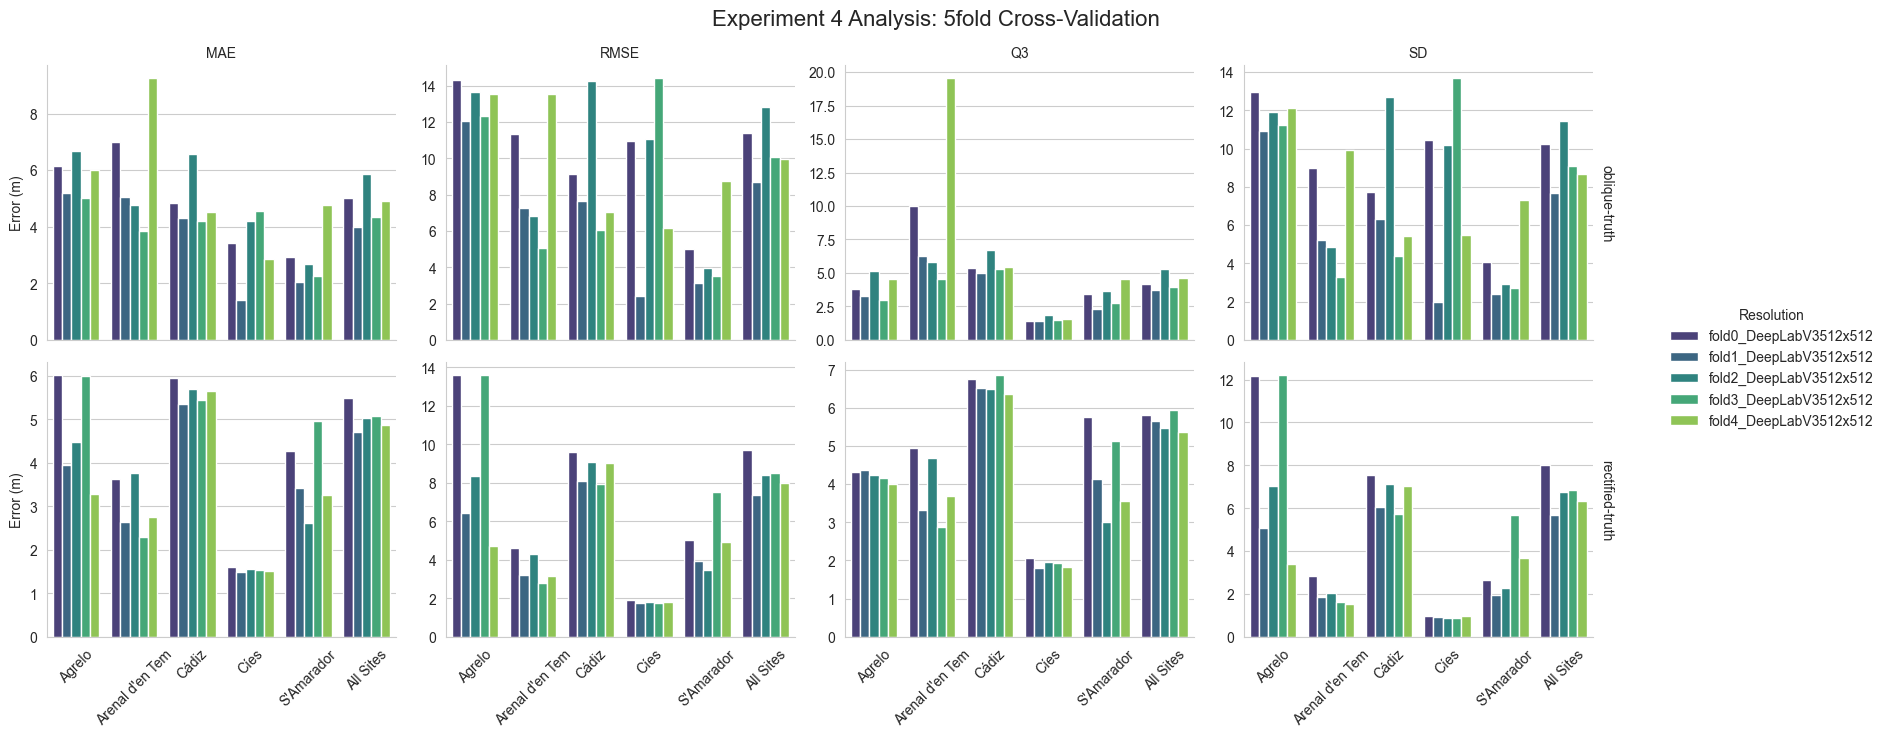

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('shoreline_validation_results_crossval.csv')

fold_filter = df['experiment'].str.contains('fold', case=False)
dir_filter = df['direction'].isin(['rectified-truth', 'oblique-truth'])
df_fold = df[fold_filter & dir_filter].copy()

print(df_fold.head())

# clean direction names
df_fold['Resolution'] = df_fold['experiment'].str.replace('fold_deeplabv3_', '')

site_mapping = {
    'agrelo': 'Agrelo',
    'arenaldentem': "Arenal d'en Tem",
    'cadiz': 'Cádiz',
    'cies': 'Cíes',
    'samarador': "S'Amarador",
    'all': 'All Sites'
}
df_fold['Site_Label'] = df_fold['site'].map(site_mapping).fillna(df_fold['site'].str.title())

metrics = ['MAE', 'RMSE', 'Q3', 'SD']
df_melted = df_fold.melt(
    id_vars=['Site_Label', 'direction', 'Resolution'], 
    value_vars=metrics, 
    var_name='Metric', 
    value_name='Value (m)'
)

sns.set_style("whitegrid")

g = sns.catplot(
    data=df_melted, 
    kind="bar",
    x="Site_Label", 
    y="Value (m)", 
    hue="Resolution",
    col="Metric", 
    row="direction",
    height=3.5, 
    aspect=1.2,
    palette="viridis", # O 'mako', 'rocket', etc.
    sharey=False,
    margin_titles=True
)

g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels("", "Error (m)")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45) 

plt.subplots_adjust(top=0.9)
g.figure.suptitle('Experiment 4 Analysis: 5fold Cross-Validation', fontsize=16)

plt.show()

# save the figure
g.savefig('experiment4_crossval_metrics.png', dpi=300)


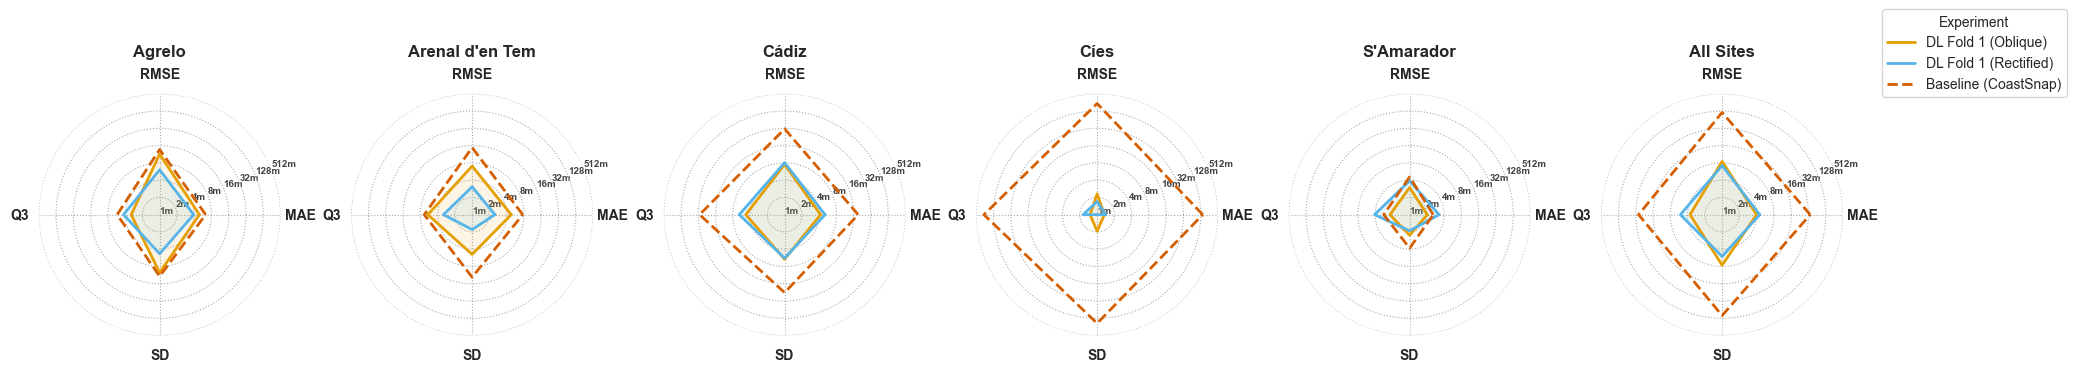

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from matplotlib.lines import Line2D

# --- 1. LOAD DATA ---
try:
    df_crossval = pd.read_csv('shoreline_validation_results_crossval.csv')
    df_baseline = pd.read_csv('shoreline_validation_results_baseline.csv')
except FileNotFoundError:
    raise

# --- 2. DATA PREPARATION ---
fold_name = [x for x in df_crossval['experiment'].unique() if 'fold1' in str(x).lower().replace('_', '')][0]
df_dl = df_crossval[df_crossval['experiment'] == fold_name].copy()
df_dl = df_dl[df_dl['direction'].isin(['oblique-truth', 'rectified-truth'])].copy()

def get_dl_label(row):
    return 'DL Fold 1 (Oblique)' if 'oblique' in row['direction'] else 'DL Fold 1 (Rectified)'
df_dl['Label'] = df_dl.apply(get_dl_label, axis=1)

df_base = df_baseline[df_baseline['direction'] == 'rectified-truth'].copy()
df_base['Label'] = 'Baseline (CoastSnap)'

cols = ['site', 'Label', 'MAE', 'RMSE', 'Q3', 'SD']
df_combined = pd.concat([df_dl[cols], df_base[cols]], ignore_index=True)

site_mapping = {'agrelo': 'Agrelo', 'arenaldentem': "Arenal d'en Tem", 'cadiz': 'Cádiz', 
                'cies': 'Cíes', 'samarador': "S'Amarador", 'all': 'All Sites'}
df_combined['Site_Label'] = df_combined['site'].map(site_mapping).fillna(df_combined['site'].str.title())

# --- 3. OPTIMIZED CONFIGURATION ---
# This dedicates 5 circles to the "good" zone (<32m) and only 2 circles to the "bad" zone.
custom_ticks = [1, 2, 4, 8, 16, 32, 128, 512]

tick_indices = np.arange(len(custom_ticks))

def transform_equidistant(values):
    values = np.maximum(values, custom_ticks[0])
    return np.interp(values, custom_ticks, tick_indices)

max_grid = tick_indices[-1] 

# --- 4. GENERATION OF GRAPHS ---
sites = df_combined['Site_Label'].unique()
metrics = ['MAE', 'RMSE', 'Q3', 'SD']
n_metrics = len(metrics)
n_sites = len(sites)

labels_order = ['DL Fold 1 (Oblique)', 'DL Fold 1 (Rectified)', 'Baseline (CoastSnap)']
colors = {'DL Fold 1 (Oblique)': '#E69F00', 'DL Fold 1 (Rectified)': '#56B4E9', 'Baseline (CoastSnap)': '#D55E00'}

fig, axes = plt.subplots(nrows=1, ncols=n_sites, figsize=(n_sites * 3.5, 5), subplot_kw=dict(polar=True))
angles = [n / float(n_metrics) * 2 * pi for n in range(n_metrics)]
angles_closed = angles + angles[:1] 

if n_sites == 1: 
    axes = [axes]

for i, site in enumerate(sites):
    ax = axes[i]
    site_data = df_combined[df_combined['Site_Label'] == site]
    
    # --- PLOT ---
    for label in labels_order:
        subset = site_data[site_data['Label'] == label]
        if not subset.empty:
            raw_values = subset[metrics].values.flatten()
            plot_values = transform_equidistant(raw_values).tolist()
            
            if len(plot_values) == n_metrics:
                plot_values += plot_values[:1] 
                ls = '--' if 'Baseline' in label else '-'
                
                ax.plot(angles_closed, plot_values, linewidth=2, linestyle=ls, label=label, color=colors[label])
                if 'Baseline' not in label:
                    ax.fill(angles_closed, plot_values, color=colors[label], alpha=0.1)

    # --- AXES ---
    ax.set_ylim(0, max_grid)
    ax.set_yticks(tick_indices)
    
    # Add 'm' to clarify that values are in meters
    labels_with_units = [f'{t}m' for t in custom_ticks]
    ax.set_yticklabels(labels_with_units, color="#444444", size=7, weight='bold')
    
    ax.set_xticks(angles)
    ax.set_xticklabels(metrics, size=10, weight='bold')
    ax.spines["polar"].set_visible(False)
    ax.grid(color='#AAAAAA', linestyle=':', linewidth=0.8)
    
    ax.set_title(f"{site}", size=12, weight='bold', y=1.12)

# Llegenda
legend_elements = [Line2D([0], [0], color=colors[l], lw=2, linestyle='--' if 'Baseline' in l else '-', label=l) for l in labels_order]
fig.legend(handles=legend_elements, loc='upper right', title='Experiment', bbox_to_anchor=(0.99, 0.85))

plt.tight_layout()
plt.subplots_adjust(top=0.82, right=0.88) 

plt.show()
# plt.savefig('spyder_optimized.png', dpi=300, bbox_inches='tight')